In [1]:
import math
import random
import torch
from torch import Tensor, nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from pathlib import Path

SEED = 7
DATA_DIR = Path('shakespeare-dataset-main/text')
BLOCK_SIZE, BATCH_SIZE, NUM_WORKERS = 64, 8, 0
N_TRAIN_SAMPLES = 8
DIM, NUM_LAYERS, NUM_HEADS, FF_DIM, DROPOUT = 128, 6, 4, 512, 0.1
DIFFUSION_STEPS, BETA_START, BETA_END = 1000, 1e-4, 0.02
LEARNING_RATE, WEIGHT_DECAY, GRAD_CLIP_NORM = 3e-4, 1e-2, 1.0
TRAIN_STEPS, LOG_EVERY, SAMPLE_EVERY = 10_000, 50, 1_000
MSE_WEIGHT, ROUNDING_WEIGHT, PRIOR_WEIGHT = 1.0, 1.0, 1.0
SAMPLE_BATCH_SIZE, SAMPLE_REVERSE_STEPS = 2, 250

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
random.seed(SEED)
print(f'Using {device}')


Using mps


In [2]:
def clean_folger_text(raw):
    lines = raw.replace('\r\n', '\n').replace('\r', '\n').splitlines(keepends=True)
    return ''.join(lines[7:]).lstrip('\n')

paths = sorted(DATA_DIR.glob('*.txt'))
if not paths:
    raise FileNotFoundError(f'No .txt files in {DATA_DIR}')
text = '\n\n'.join(clean_folger_text(p.read_text(encoding='utf-8')) for p in paths)
chars = sorted(set(text))
stoi = {char: index for index, char in enumerate(chars)}
itos = dict(enumerate(chars))
tokens = torch.tensor([stoi[c] for c in text], dtype=torch.long)

class CharacterBlocks(Dataset):
    def __init__(self, values, block_size):
        self.values = values
        self.block_size = block_size
    def __len__(self): return len(self.values) // self.block_size
    def __getitem__(self, index):
        start = index * self.block_size
        return self.values[start:start + self.block_size]

full_dataset = CharacterBlocks(tokens, BLOCK_SIZE)
if not 1 <= N_TRAIN_SAMPLES <= len(full_dataset):
    raise ValueError(f'N_TRAIN_SAMPLES must be between 1 and {len(full_dataset)}')
selected_indices = sorted(random.Random(SEED).sample(range(len(full_dataset)), N_TRAIN_SAMPLES))
dataset = torch.utils.data.Subset(full_dataset, selected_indices)
loader = DataLoader(dataset, batch_size=min(BATCH_SIZE, N_TRAIN_SAMPLES), shuffle=True, drop_last=False, num_workers=NUM_WORKERS)
training_blocks = torch.stack([dataset[i] for i in range(len(dataset))])
print(f'Loaded {len(paths)} works | {len(text):,} characters | vocab={len(chars)} | training blocks={len(dataset)}')
for i, block in enumerate(training_blocks):
    print(f'Train block {i} (source block {selected_indices[i]}): {repr("".join(itos[token.item()] for token in block))}')


Loaded 42 works | 5,319,139 characters | vocab=84 | training blocks=8
Train block 0 (source block 6328): 'ot dream or be not frantic--\nAs I do trust I am not--then, dear '
Train block 1 (source block 9494): 'o more.\n\nCORIOLANUS  What is the matter,\nThat, being passed for '
Train block 2 (source block 12337): '-My friends,\nThe boy hath taught us manly duties. Let us\nFind ou'
Train block 3 (source block 19772): ' in\nact and use. Hereof comes it that Prince Harry is\nvaliant, f'
Train block 4 (source block 42445): "ere's no bottom, none,\nIn my voluptuousness. Your wives, your da"
Train block 5 (source block 47931): 'y whole course of wooing, thou cried\'st\n"Indeed?"\nAnd didst cont'
Train block 6 (source block 51750): ' exchequer of the poor,\nWhich, till my infant fortune comes to y'
Train block 7 (source block 70239): 'by Lords and Soldiers.\nEntering through another door, the three '


In [3]:
class GaussianEmbedding(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        token_var = 0.05
        mean_var = 1.0 - token_var

        std_init = math.sqrt(token_var)
        raw_std_init = math.log(math.expm1(std_init))

        self.mu = nn.Parameter(torch.randn(vocab_size, dim) * math.sqrt(mean_var))
        self.raw_std = nn.Parameter(torch.full((vocab_size, dim), raw_std_init))
    @property
    def std(self):
        return F.softplus(self.raw_std)
    def sample(self, ids):
        mean = self.mu[ids]
        return mean + self.std[ids] * torch.randn_like(mean)
    def squared_distances(self, vectors):
        return (vectors.square().sum(-1, keepdim=True) + self.mu.square().sum(-1) - 2 * vectors @ self.mu.T)
    def comp_mean(self):
        #Square magnitude of the mean of the embedding means, averaged over dimensions
        return self.mu.mean(dim=0).square().mean()
    def comp_variance(self):
        #Composed variance of the embedding, averaged over dimensions
        return (self.std.square().mean(dim=0) + self.mu.var(dim=0, correction=0)).sum()
    def mean_variance(self):
        #Mean of the embedding variances, averaged over dimensions
        return self.std.square().mean(dim=0)

# Model 
class SimpleGaussianDiffusionLM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = GaussianEmbedding(vocab_size, DIM)
        self.position = nn.Embedding(BLOCK_SIZE, DIM)

        frequencies = torch.exp(-math.log(10_000) * torch.arange(DIM // 2) / (DIM // 2))
        self.register_buffer('time_frequencies', frequencies)
        layer = nn.TransformerEncoderLayer(DIM, NUM_HEADS, FF_DIM, DROPOUT, batch_first=True, norm_first=False, activation='gelu')
        self.transformer = nn.TransformerEncoder(layer, NUM_LAYERS)
        self.final_norm, self.x0_head = nn.LayerNorm(DIM), nn.Linear(DIM, DIM)
    def forward(self, x_t, timesteps):
        pos = torch.arange(x_t.size(1), device=x_t.device)
        angles = timesteps[:, None] * self.time_frequencies
        time_embedding = torch.cat((angles.sin(), angles.cos()), dim=-1)
        hidden = x_t + self.position(pos).unsqueeze(0) + time_embedding.unsqueeze(1)
        return self.x0_head(self.final_norm(self.transformer(hidden)))
    def rounding_logits(self, vectors): return -self.embedding.squared_distances(vectors)
    def round_to_tokens(self, vectors): return self.rounding_logits(vectors).argmax(-1)

model = SimpleGaussianDiffusionLM(len(chars)).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')


Parameters: 1,236,096


In [4]:
betas = torch.linspace(BETA_START, BETA_END, DIFFUSION_STEPS, device=device)
alpha_bar = torch.cat((torch.ones(1, device=device), torch.cumprod(1 - betas, 0)))

def q_sample(x0, t):
    alpha = alpha_bar[t].view(-1, 1, 1)
    return alpha.sqrt() * x0 + (1 - alpha).sqrt() * torch.randn_like(x0)

def loss_terms(ids):
    x0 = model.embedding.sample(ids)
    t = torch.randint(1, DIFFUSION_STEPS + 1, (ids.size(0),), device=device)
    prediction = model(q_sample(x0, t), t)
    mse = F.mse_loss(prediction, x0)
    rounding = F.cross_entropy(model.rounding_logits(x0).flatten(0, 1), ids.flatten())

    prior_loss = (model.embedding.comp_mean()) + (DIM - model.embedding.comp_variance())**2

    weighted_mse = MSE_WEIGHT * mse
    weighted_rounding = ROUNDING_WEIGHT * rounding
    weighted_prior = PRIOR_WEIGHT * prior_loss

    total = weighted_mse + weighted_rounding + weighted_prior
    return total, weighted_mse, weighted_rounding, weighted_prior
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


In [5]:
def step(batch):
    optimizer.zero_grad(set_to_none=True)
    values = loss_terms(batch.to(device))
    values[0].backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
    optimizer.step()

    return *values, grad_norm

def train(steps=TRAIN_STEPS):
    model.train()
    iterator = iter(loader)
    running = torch.zeros(5)
    for number in range(1, steps + 1):
        try: batch = next(iterator)
        except StopIteration:
            iterator = iter(loader)
            batch = next(iterator)
        values = step(batch)
        running += torch.tensor([value.item() for value in values])
        if number % LOG_EVERY == 0 or number == steps:
            mean = running / min(LOG_EVERY, number)
            print(
                f'step {number}/{steps} | total={mean[0]:.4f} | '
                f'weighted_mse={mean[1]:.4f} | weighted_rounding={mean[2]:.4f} | weighted_prior={mean[3]:.6f} | '
                f'grad_norm={mean[4]:.4f}'
            )
            running.zero_()
        if number % SAMPLE_EVERY == 0:
            print(f'\nSamples at step {number}:')
            sampled = sample().cpu()
            mismatches = (sampled[:, None, :] != training_blocks[None, :, :]).sum(-1)
            for token_block, nearest in zip(sampled, mismatches.min(dim=1).values):
                print(f'Nearest training block: {nearest.item()}/{BLOCK_SIZE} character mismatches')
                print(''.join(itos[token.item()] for token in token_block))
                print()
            print('Denoising on training blocks:')
            for t, mse, accuracy in reconstruction_diagnostics():
                print(f'  t={t:4d} | mse={mse:.4f} | token_accuracy={accuracy:.1%}')


In [6]:
@torch.no_grad()
def sample(batch_size=SAMPLE_BATCH_SIZE, reverse_steps=SAMPLE_REVERSE_STEPS):
    was_training = model.training
    model.eval()
    x_t = torch.randn(batch_size, BLOCK_SIZE, DIM, device=device)
    times = torch.linspace(DIFFUSION_STEPS, 0, reverse_steps + 1, device=device).long()
    for current, next_time in zip(times[:-1], times[1:]):
        t = torch.full((batch_size,), current, device=device, dtype=torch.long)
        x0_hat = model(x_t, t)
        a_t, a_next = alpha_bar[current], alpha_bar[next_time]
        eps_hat = (x_t - a_t.sqrt() * x0_hat) / (1 - a_t).sqrt().clamp_min(1e-8)
        x_t = a_next.sqrt() * x0_hat + (1 - a_next).sqrt() * eps_hat
    result = model.round_to_tokens(x_t)
    model.train(was_training)
    return result

@torch.no_grad()
def reconstruction_diagnostics(timesteps=(1, 10, 100, 500, 1000)):
    was_training = model.training
    model.eval()
    ids = training_blocks.to(device)
    x0 = model.embedding.sample(ids)
    results = []
    for timestep in timesteps:
        t = torch.full((ids.size(0),), timestep, device=device, dtype=torch.long)
        prediction = model(q_sample(x0, t), t)
        mse = F.mse_loss(prediction, x0).item()
        accuracy = (model.round_to_tokens(prediction) == ids).float().mean().item()
        results.append((timestep, mse, accuracy))
    model.train(was_training)
    return results

train()


step 50/10000 | total=1.9369 | weighted_mse=0.9507 | weighted_rounding=0.0000 | weighted_prior=0.986219 | grad_norm=3.5472
step 100/10000 | total=0.7660 | weighted_mse=0.7531 | weighted_rounding=0.0000 | weighted_prior=0.012847 | grad_norm=0.2436
step 150/10000 | total=0.6180 | weighted_mse=0.6067 | weighted_rounding=0.0000 | weighted_prior=0.011232 | grad_norm=0.1519
step 200/10000 | total=0.5918 | weighted_mse=0.5806 | weighted_rounding=0.0000 | weighted_prior=0.011166 | grad_norm=0.1553
step 250/10000 | total=0.5422 | weighted_mse=0.5311 | weighted_rounding=0.0000 | weighted_prior=0.011101 | grad_norm=0.1553
step 300/10000 | total=0.4709 | weighted_mse=0.4598 | weighted_rounding=0.0000 | weighted_prior=0.011031 | grad_norm=0.1666
step 350/10000 | total=0.4810 | weighted_mse=0.4700 | weighted_rounding=0.0000 | weighted_prior=0.010956 | grad_norm=0.1795
step 400/10000 | total=0.4914 | weighted_mse=0.4805 | weighted_rounding=0.0000 | weighted_prior=0.010878 | grad_norm=0.1720
step 450/

In [22]:
for token_block in sample(reverse_steps=15).cpu():
                print(''.join(itos[token.item()] for token in token_block))
                print()

 in
act and use. Hereof comes it that Prince Harry is
valiant, f

 exchequer of the poor,
Which, till my infant fortune comes to y



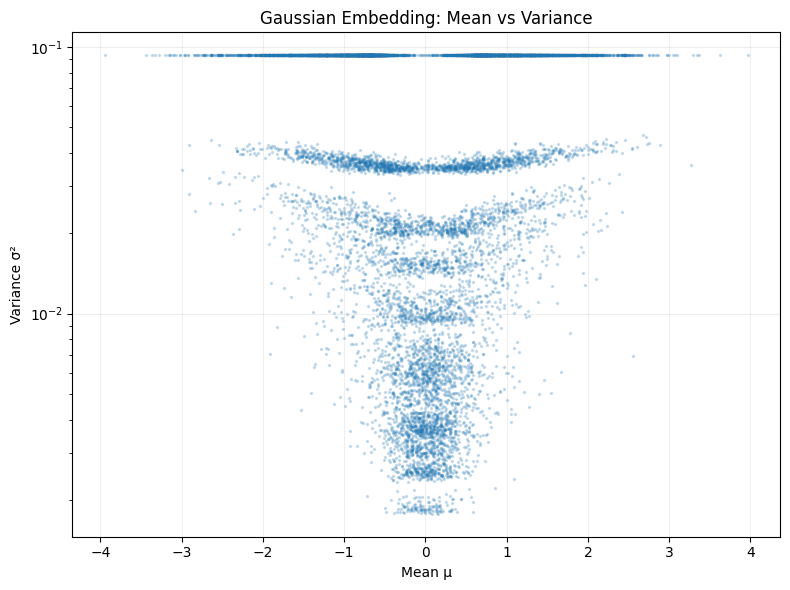

In [25]:
import matplotlib.pyplot as plt

mu = model.embedding.mu.detach().flatten().cpu()
var = F.softplus(
    model.embedding.raw_std.detach()
).square().flatten().cpu()

# Subsample if vocab_size * dim is huge
if mu.numel() > 50000:
    idx = torch.randperm(mu.numel())[:50000]
    mu = mu[idx]
    var = var[idx]

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(mu.numpy(), var.numpy(), s=2, alpha=0.2)
ax.set_yscale("log")

ax.set_xlabel("Mean μ")
ax.set_ylabel("Variance σ²")
ax.set_title("Gaussian Embedding: Mean vs Variance")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()